## Comparison Notebook
This notebook creates visualizations to summarize all results and compare models 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

---
## Binary Classification: Stable vs At-Risk

In [2]:
# Best Binary Model Metrics


binary_results = pd.DataFrame([
    {
        'Model': 'Random Forest\n(balanced_subsample)',
        'Recall (At-Risk)': 0.73, 'Recall (Stable)': 0.74, 'Macro Recall': 0.7371,
        'F1 (At-Risk)': 0.57, 'F1 (Stable)': 0.81, 'Macro F1': 0.6908,
        'Precision (At-Risk)': 0.46, 'Precision (Stable)': 0.90,
        'Accuracy': 0.7401, 'Weighted F1': 0.7567,
    },
    {
        'Model': 'XGBoost\n(default threshold)',
        'Recall (At-Risk)': 0.77, 'Recall (Stable)': 0.72, 'Macro Recall': 0.7423,
        'F1 (At-Risk)': 0.57, 'F1 (Stable)': 0.80, 'Macro F1': 0.6858,
        'Precision (At-Risk)': 0.45, 'Precision (Stable)': 0.91,
        'Accuracy': 0.7293, 'Weighted F1': 0.75,
    },
])

# Recall columns first (primary metric), then F1 (secondary)
display_cols = ['Model',
                'Recall (At-Risk)', 'Recall (Stable)', 'Macro Recall',
                'F1 (At-Risk)', 'F1 (Stable)', 'Macro F1',
                'Accuracy']

print('=' * 90)
print('BEST BINARY MODELS — Performance on 2024 Holdout (n=308,479)')
print('Sorted by primary metric: At-Risk Recall')
print('=' * 90)
display(binary_results[display_cols].style
        .format(precision=4, subset=display_cols[1:])
        .set_caption('Binary Classification: Stable (0) vs At-Risk (1)')
        .highlight_max(axis=0, subset=display_cols[1:], props='font-weight:bold; color:darkgreen'))

print('\n--- XGBoost Threshold Tradeoff ---')
print('XGBoost supports threshold tuning to trade off recall vs F1:')
print(f'  Default     (θ=0.500): At-Risk Recall = 0.77  |  Macro F1 = 0.6858')
print(f'  High-Recall (θ=0.462): At-Risk Recall = 0.80  |  Macro F1 = 0.6725')
print(f'  Optimized-F1(θ=0.568): At-Risk Recall = 0.70  |  Macro F1 = 0.7031')
print(f'\nThe default threshold offers the best balance of recall and F1.')
print(f'Optimizing for F1 (θ=0.568) gains +0.017 Macro F1 but loses 0.07 At-Risk Recall.')

BEST BINARY MODELS — Performance on 2024 Holdout (n=308,479)
Sorted by primary metric: At-Risk Recall


,Model,Recall (At-Risk),Recall (Stable),Macro Recall,F1 (At-Risk),F1 (Stable),Macro F1,Accuracy
0,Random Forest (balanced_subsample),0.7300,0.7400,0.7371,0.5700,0.8100,0.6908,0.7401
1,XGBoost (default threshold),0.7700,0.7200,0.7423,0.5700,0.8000,0.6858,0.7293



--- XGBoost Threshold Tradeoff ---
XGBoost supports threshold tuning to trade off recall vs F1:
  Default     (θ=0.500): At-Risk Recall = 0.77  |  Macro F1 = 0.6858
  High-Recall (θ=0.462): At-Risk Recall = 0.80  |  Macro F1 = 0.6725
  Optimized-F1(θ=0.568): At-Risk Recall = 0.70  |  Macro F1 = 0.7031

The default threshold offers the best balance of recall and F1.
Optimizing for F1 (θ=0.568) gains +0.017 Macro F1 but loses 0.07 At-Risk Recall.


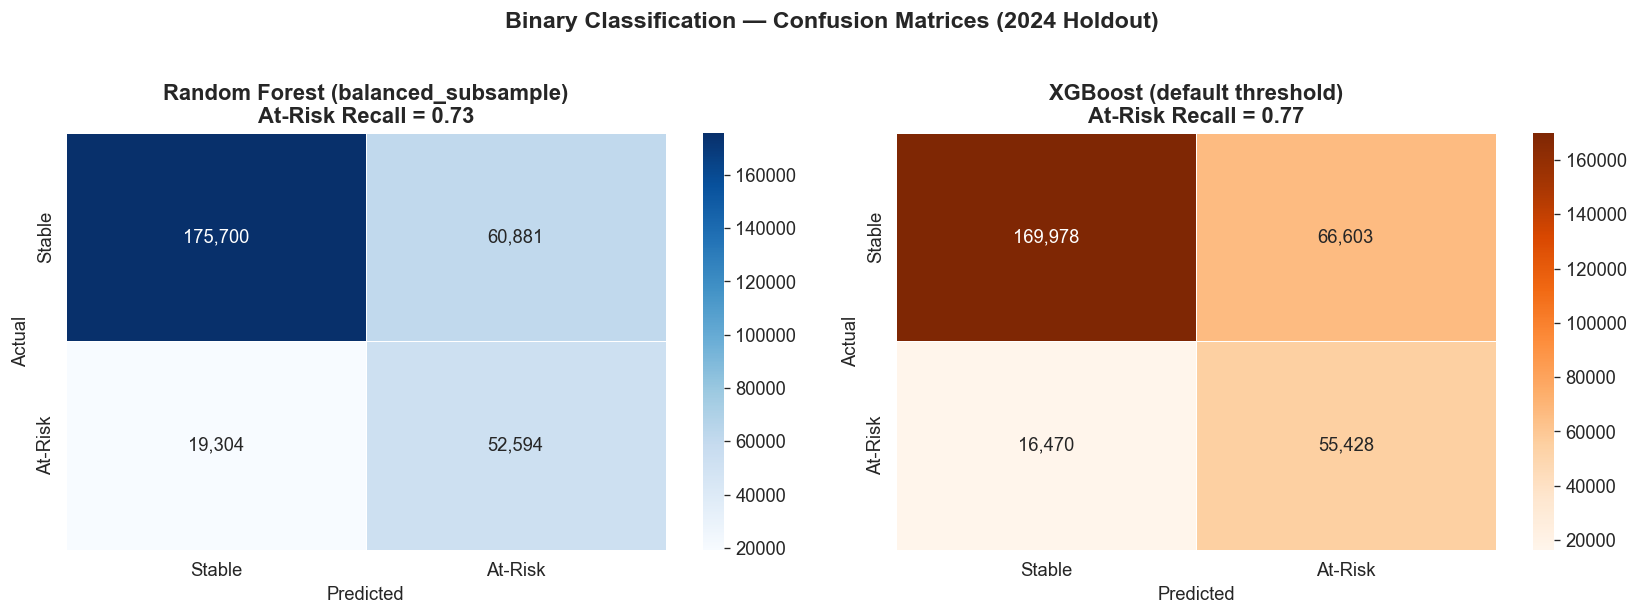

XGBoost identifies 55,428 of 71,898 at-risk individuals (77%), missing 16,470.
Random Forest identifies 52,594 of 71,898 (73%), missing 19,304.
XGBoost catches 2,834 more at-risk individuals than RF (+4pp recall).


In [3]:
# Binary Confusion Matrices 
binary_labels = ['Stable', 'At-Risk']

# Random Forest (balanced_subsample, engineered features)
cm_rf_bin = np.array([
    [175700, 60881],
    [ 19304, 52594]
])

# XGBoost (default threshold = 0.5)
cm_xgb_bin = np.array([
    [169978, 66603],
    [ 16470, 55428]
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title, cmap in zip(
    axes,
    [cm_rf_bin, cm_xgb_bin],
    ['Random Forest (balanced_subsample)\nAt-Risk Recall = 0.73',
     'XGBoost (default threshold)\nAt-Risk Recall = 0.77'],
    ['Blues', 'Oranges']
):
    sns.heatmap(cm, annot=True, fmt=',d', cmap=cmap, ax=ax,
                xticklabels=binary_labels, yticklabels=binary_labels,
                linewidths=0.5, linecolor='white')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Binary Classification — Confusion Matrices (2024 Holdout)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('XGBoost identifies 55,428 of 71,898 at-risk individuals (77%), missing 16,470.')
print('Random Forest identifies 52,594 of 71,898 (73%), missing 19,304.')
print(f'XGBoost catches {55428-52594:,} more at-risk individuals than RF (+4pp recall).')

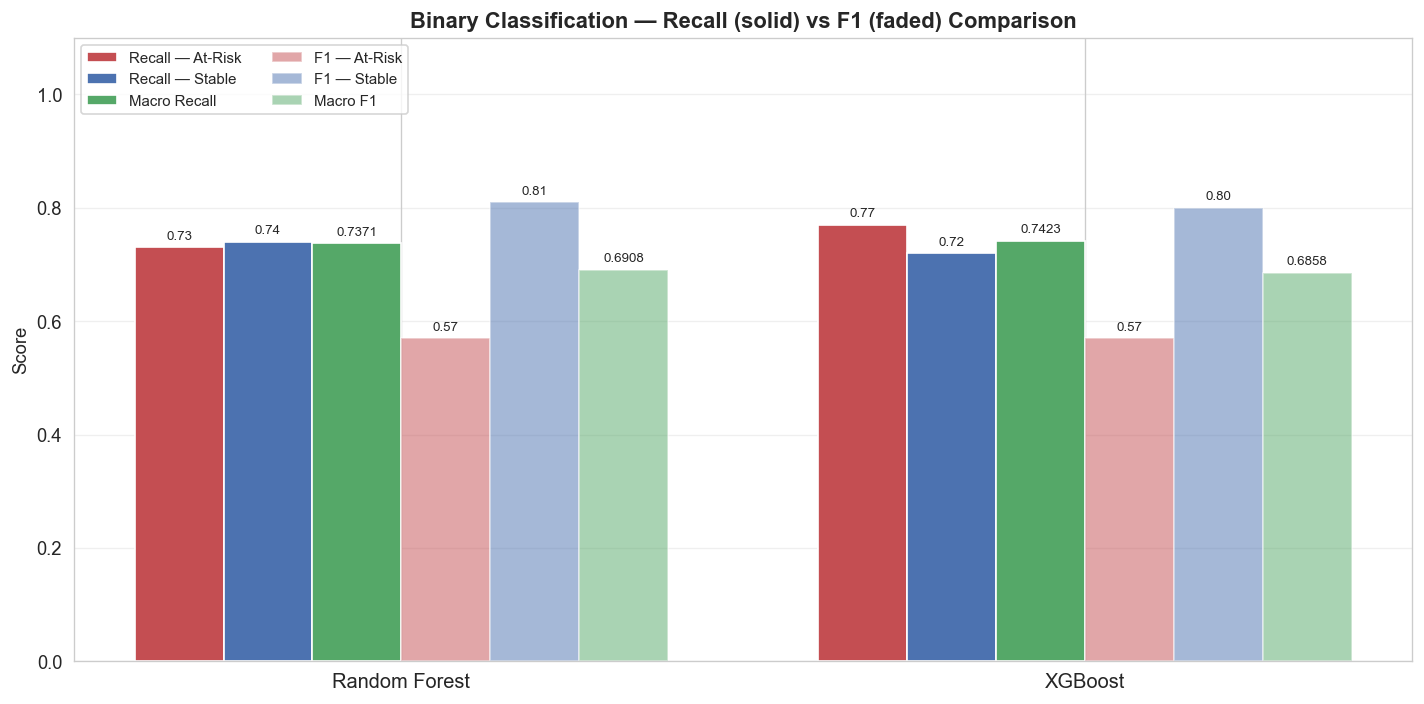

XGBoost achieves higher At-Risk Recall (0.77 vs 0.73) — the primary metric.
RF achieves marginally higher Macro F1 (0.6908 vs 0.6858) — the secondary metric.
Given our recall priority, XGBoost is the preferred binary model.


In [4]:
# Binary: Recall & F1 Comparison
models_bin = ['Random Forest', 'XGBoost']

recall_at_risk = [0.73, 0.77]
recall_stable  = [0.74, 0.72]
f1_at_risk     = [0.57, 0.57]
f1_stable      = [0.81, 0.80]
macro_recall   = [0.7371, 0.7423]
macro_f1       = [0.6908, 0.6858]

x = np.arange(len(models_bin))
width = 0.13

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - 2.5*width, recall_at_risk, width, label='Recall — At-Risk',  color='#C44E52')
bars2 = ax.bar(x - 1.5*width, recall_stable,  width, label='Recall — Stable',   color='#4C72B0')
bars3 = ax.bar(x - 0.5*width, macro_recall,   width, label='Macro Recall',       color='#55A868')
bars4 = ax.bar(x + 0.5*width, f1_at_risk,     width, label='F1 — At-Risk',       color='#C44E52', alpha=0.5)
bars5 = ax.bar(x + 1.5*width, f1_stable,      width, label='F1 — Stable',        color='#4C72B0', alpha=0.5)
bars6 = ax.bar(x + 2.5*width, macro_f1,       width, label='Macro F1',           color='#55A868', alpha=0.5)

for bars, fmt in [(bars1,'%.2f'), (bars2,'%.2f'), (bars3,'%.4f'),
                  (bars4,'%.2f'), (bars5,'%.2f'), (bars6,'%.4f')]:
    ax.bar_label(bars, fmt=fmt, padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(models_bin, fontsize=12)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Binary Classification — Recall (solid) vs F1 (faded) Comparison', fontweight='bold')
ax.legend(ncol=2, fontsize=9, loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('XGBoost achieves higher At-Risk Recall (0.77 vs 0.73) — the primary metric.')
print('RF achieves marginally higher Macro F1 (0.6908 vs 0.6858) — the secondary metric.')
print('Given our recall priority, XGBoost is the preferred binary model.')

---
## Multiclass Classification: 4-Class Poverty Severity

Classes: **Stable (0)**, **Near Poverty (1)**, **Poverty (2)**, **Deep Poverty (3)**

In [5]:
# Best Multiclass (4-Class) Model Metrics
# Source: 4a_Baseline.ipynb  (Logistic Regression, class_weight='balanced')
# Source: 4b_RandomForest_Model.ipynb  (balanced_subsample, 4-class)
# Source: 4c_XGBoost_Model.ipynb  (sample-weighted, 4-class)
# Source: 5_Feature_Transformer/FT-Model-Build.ipynb  (FT-Transformer, argmax)

multi_results = pd.DataFrame([
    {
        'Model': 'Baseline\n(Logistic Reg)',
        'Recall Stable': 0.67, 'Recall Near Poverty': 0.29,
        'Recall Poverty': 0.27, 'Recall Deep Poverty': 0.60,
        'Avg Poverty Recall': round((0.29+0.27+0.60)/3, 4),
        'Macro Recall': round((0.67+0.29+0.27+0.60)/4, 4),
        'F1 Stable': 0.77, 'F1 Near Poverty': 0.25,
        'F1 Poverty': 0.18, 'F1 Deep Poverty': 0.30,
        'Macro F1': 0.38, 'Weighted F1': 0.65,
        'Accuracy': 0.60, 'ROC AUC (OvR)': 0.7582,
    },
    {
        'Model': 'Random Forest\n(balanced_subsample)',
        'Recall Stable': 0.68, 'Recall Near Poverty': 0.41,
        'Recall Poverty': 0.28, 'Recall Deep Poverty': 0.51,
        'Avg Poverty Recall': round((0.41+0.28+0.51)/3, 4),
        'Macro Recall': round((0.68+0.41+0.28+0.51)/4, 4),
        'F1 Stable': 0.78, 'F1 Near Poverty': 0.30,
        'F1 Poverty': 0.20, 'F1 Deep Poverty': 0.34,
        'Macro F1': 0.40, 'Weighted F1': 0.67,
        'Accuracy': 0.62, 'ROC AUC (OvR)': 0.7759,
    },
    {
        'Model': 'XGBoost\n(sample-weighted)',
        'Recall Stable': 0.65, 'Recall Near Poverty': 0.40,
        'Recall Poverty': 0.34, 'Recall Deep Poverty': 0.54,
        'Avg Poverty Recall': round((0.40+0.34+0.54)/3, 4),
        'Macro Recall': round((0.65+0.40+0.34+0.54)/4, 4),
        'F1 Stable': 0.76, 'F1 Near Poverty': 0.29,
        'F1 Poverty': 0.21, 'F1 Deep Poverty': 0.34,
        'Macro F1': 0.40, 'Weighted F1': 0.65,
        'Accuracy': 0.60, 'ROC AUC (OvR)': np.nan,
    },
    {
        'Model': 'FT-Transformer\n(argmax)',
        'Recall Stable': 0.81, 'Recall Near Poverty': 0.46,
        'Recall Poverty': 0.08, 'Recall Deep Poverty': 0.39,
        'Avg Poverty Recall': round((0.46+0.08+0.39)/3, 4),
        'Macro Recall': round((0.81+0.46+0.08+0.39)/4, 4),
        'F1 Stable': 0.84, 'F1 Near Poverty': 0.34,
        'F1 Poverty': 0.12, 'F1 Deep Poverty': 0.38,
        'Macro F1': 0.42, 'Weighted F1': 0.72,
        'Accuracy': 0.71, 'ROC AUC (OvR)': np.nan,
    },
])

# Recall columns first (primary), then F1 (secondary)
display_cols_m = ['Model',
                  'Recall Near Poverty', 'Recall Poverty', 'Recall Deep Poverty',
                  'Avg Poverty Recall', 'Macro Recall',
                  'F1 Near Poverty', 'F1 Poverty', 'F1 Deep Poverty',
                  'Macro F1', 'Accuracy']

print('=' * 100)
print('BEST MULTICLASS (4-CLASS) MODELS — Performance on 2024 Holdout')
print('Sorted by primary metric: Average Poverty Recall (classes 1, 2, 3)')
print('=' * 100)
display(multi_results[display_cols_m].style
        .format(precision=4, subset=display_cols_m[1:], na_rep='—')
        .set_caption('4-Class: Stable / Near Poverty / Poverty / Deep Poverty')
        .highlight_max(axis=0, subset=display_cols_m[1:], props='font-weight:bold; color:darkgreen'))

print('\n--- Poverty Recall Summary ---')
for _, row in multi_results.iterrows():
    model = row['Model'].replace('\n', ' ')
    print(f"  {model:35s}  Avg Poverty Recall = {row['Avg Poverty Recall']:.4f}  |  Macro F1 = {row['Macro F1']:.4f}")
print(f'\nXGBoost identifies the highest share of poverty-class individuals (avg recall = 0.4267).')
print(f'FT-Transformer (argmax) achieves the highest Macro F1 (0.42) and best Stable recall (0.81)')
print(f'but struggles with Poverty class recall (0.08).')
print(f'\nNote: FT-Transformer uses a separate preprocessing pipeline (n=304,368 test);')
print(f'Baseline/RF/XGBoost share the same pipeline (n=308,479 test).')

BEST MULTICLASS (4-CLASS) MODELS — Performance on 2024 Holdout
Sorted by primary metric: Average Poverty Recall (classes 1, 2, 3)


,Model,Recall Near Poverty,Recall Poverty,Recall Deep Poverty,Avg Poverty Recall,Macro Recall,F1 Near Poverty,F1 Poverty,F1 Deep Poverty,Macro F1,Accuracy
0,Baseline (Logistic Reg),0.2900,0.2700,0.6000,0.3867,0.4575,0.2500,0.1800,0.3000,0.3800,0.6000
1,Random Forest (balanced_subsample),0.4100,0.2800,0.5100,0.4000,0.4700,0.3000,0.2000,0.3400,0.4000,0.6200
2,XGBoost (sample-weighted),0.4000,0.3400,0.5400,0.4267,0.4825,0.2900,0.2100,0.3400,0.4000,0.6000
3,FT-Transformer (argmax),0.4600,0.0800,0.3900,0.3100,0.4350,0.3400,0.1200,0.3800,0.4200,0.7100



--- Poverty Recall Summary ---
  Baseline (Logistic Reg)              Avg Poverty Recall = 0.3867  |  Macro F1 = 0.3800
  Random Forest (balanced_subsample)   Avg Poverty Recall = 0.4000  |  Macro F1 = 0.4000
  XGBoost (sample-weighted)            Avg Poverty Recall = 0.4267  |  Macro F1 = 0.4000
  FT-Transformer (argmax)              Avg Poverty Recall = 0.3100  |  Macro F1 = 0.4200

XGBoost identifies the highest share of poverty-class individuals (avg recall = 0.4267).
FT-Transformer (argmax) achieves the highest Macro F1 (0.42) and best Stable recall (0.81)
but struggles with Poverty class recall (0.08).

Note: FT-Transformer uses a separate preprocessing pipeline (n=304,368 test);
Baseline/RF/XGBoost share the same pipeline (n=308,479 test).


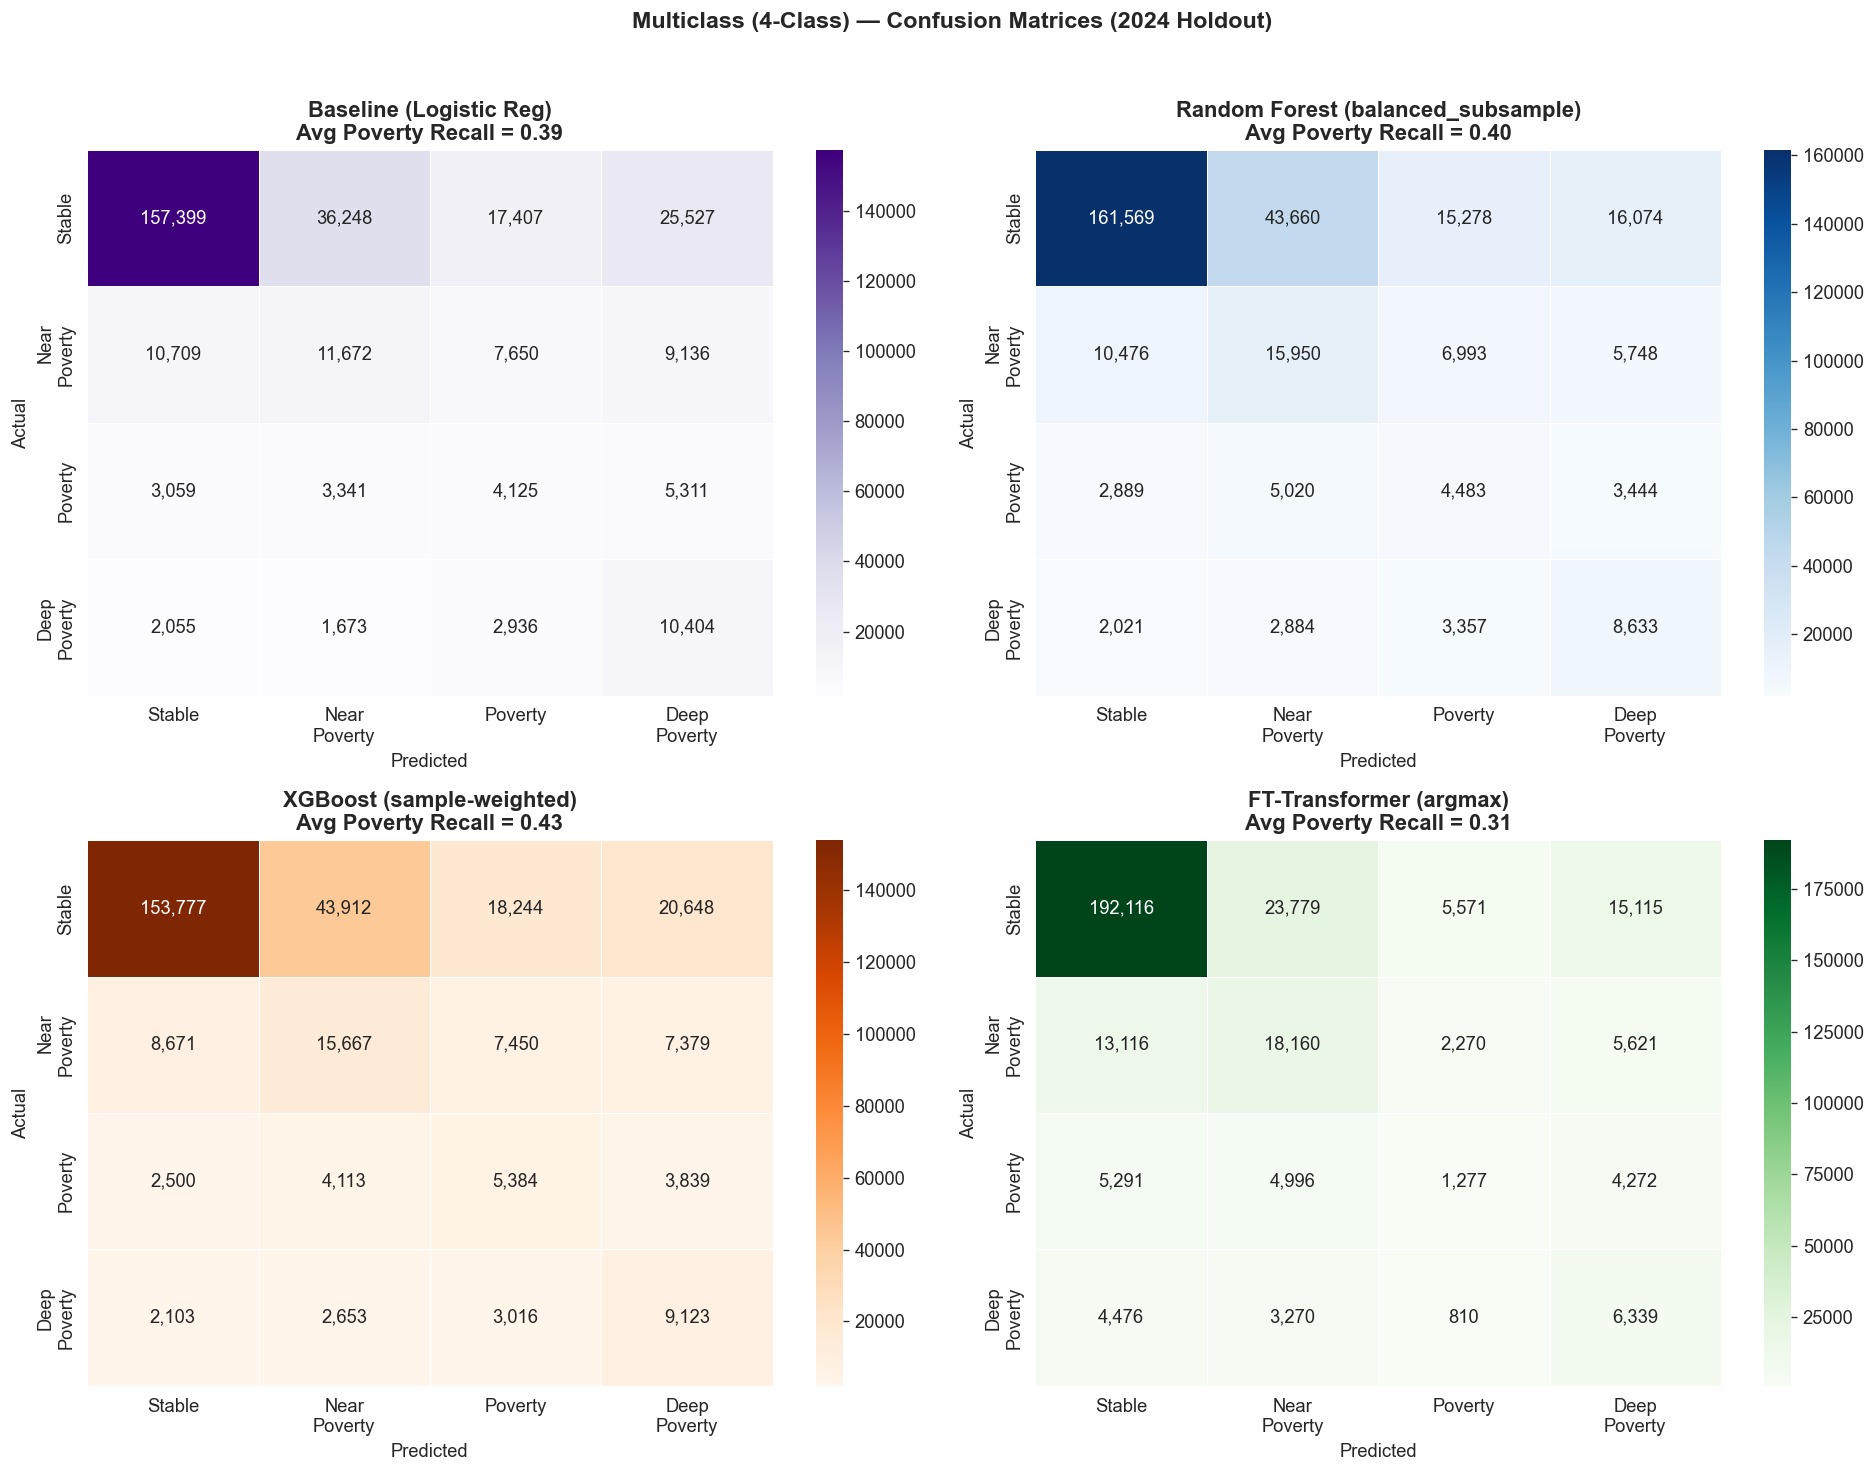

In [6]:
# Multiclass Confusion Matrices

multi_labels = ['Stable', 'Near\nPoverty', 'Poverty', 'Deep\nPoverty']

# Baseline (Logistic Regression)
cm_base = np.array([
    [157399, 36248, 17407, 25527],
    [ 10709, 11672,  7650,  9136],
    [  3059,  3341,  4125,  5311],
    [  2055,  1673,  2936, 10404]
])

# Random Forest (balanced_subsample)
cm_rf_multi = np.array([
    [161569, 43660, 15278, 16074],
    [ 10476, 15950,  6993,  5748],
    [  2889,  5020,  4483,  3444],
    [  2021,  2884,  3357,  8633]
])

# XGBoost (sample-weighted)
cm_xgb_multi = np.array([
    [153777, 43912, 18244, 20648],
    [  8671, 15667,  7450,  7379],
    [  2500,  4113,  5384,  3839],
    [  2103,  2653,  3016,  9123]
])

# FT-Transformer (argmax predictions)
cm_ft_multi = np.array([
    [192116, 23779,  5571, 15115],
    [ 13116, 18160,  2270,  5621],
    [  5291,  4996,  1277,  4272],
    [  4476,  3270,   810,  6339]
])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cms    = [cm_base, cm_rf_multi, cm_xgb_multi, cm_ft_multi]
titles = [
    'Baseline (Logistic Reg)\nAvg Poverty Recall = 0.39',
    'Random Forest (balanced_subsample)\nAvg Poverty Recall = 0.40',
    'XGBoost (sample-weighted)\nAvg Poverty Recall = 0.43',
    'FT-Transformer (argmax)\nAvg Poverty Recall = 0.31',
]
cmaps = ['Purples', 'Blues', 'Oranges', 'Greens']

for ax, cm, title, cmap in zip(axes.flat, cms, titles, cmaps):
    sns.heatmap(cm, annot=True, fmt=',d', cmap=cmap, ax=ax,
                xticklabels=multi_labels, yticklabels=multi_labels,
                linewidths=0.5, linecolor='white')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Multiclass (4-Class) — Confusion Matrices (2024 Holdout)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

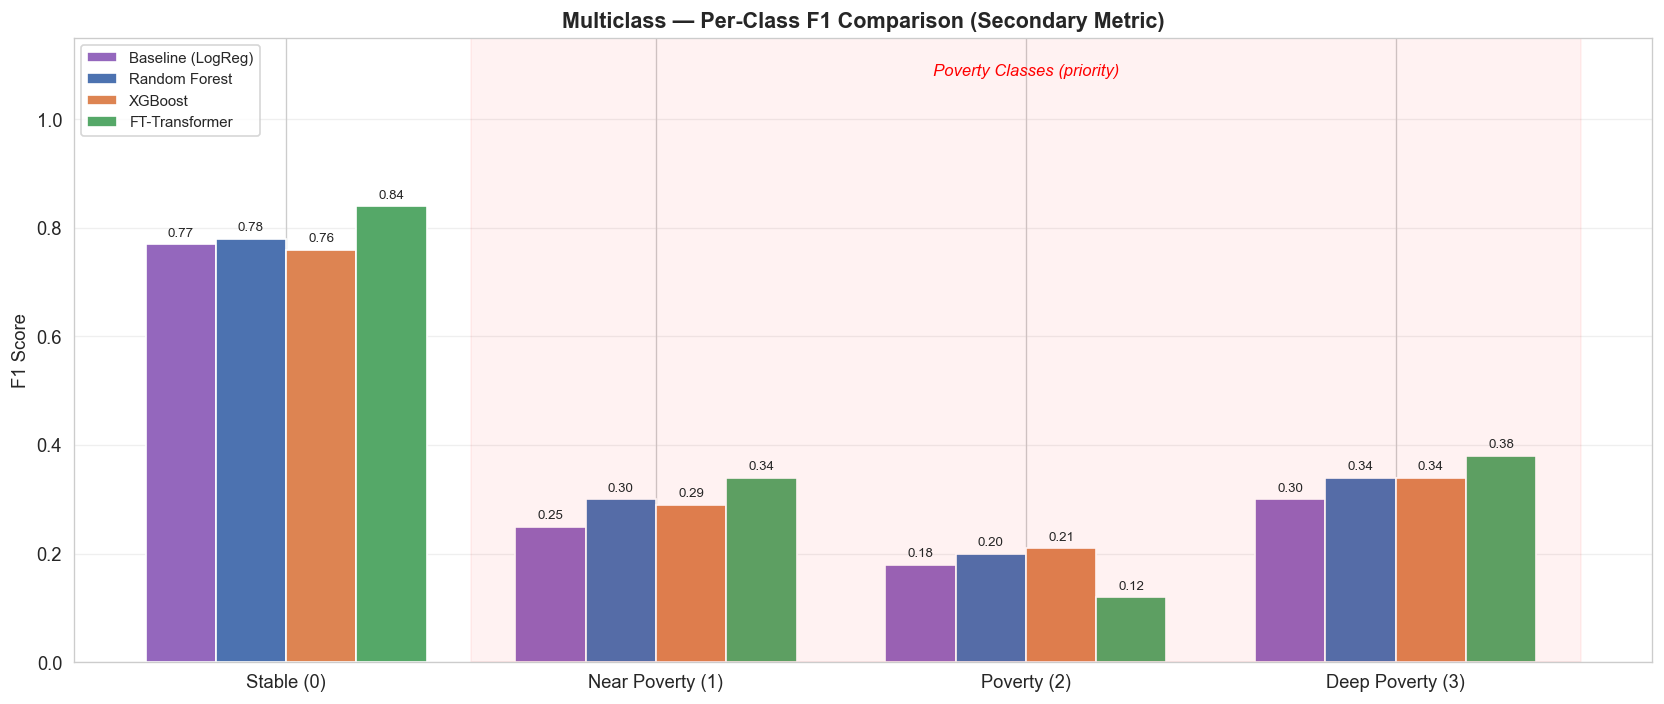

FT-Transformer (argmax) achieves the highest Macro F1 (0.42) and leads on Stable (0.84),
Near Poverty (0.34), and Deep Poverty (0.38) F1, but has the lowest Poverty F1 (0.12).
XGBoost and RF maintain the most balanced F1 across all poverty classes.


In [7]:
# Multiclass: Per-Class F1 Grouped Bar Chart (SECONDARY METRIC)
classes_4 = ['Stable (0)', 'Near Poverty (1)', 'Poverty (2)', 'Deep Poverty (3)']
models_multi = ['Baseline (LogReg)', 'Random Forest', 'XGBoost', 'FT-Transformer']
x = np.arange(len(classes_4))
width = 0.19

f1_baseline = [0.77, 0.25, 0.18, 0.30]
f1_rf       = [0.78, 0.30, 0.20, 0.34]
f1_xgb      = [0.76, 0.29, 0.21, 0.34]
f1_ft       = [0.84, 0.34, 0.12, 0.38]

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - 1.5*width, f1_baseline, width, label='Baseline (LogReg)',  color='#9467BD')
bars2 = ax.bar(x - 0.5*width, f1_rf,       width, label='Random Forest',      color='#4C72B0')
bars3 = ax.bar(x + 0.5*width, f1_xgb,      width, label='XGBoost',            color='#DD8452')
bars4 = ax.bar(x + 1.5*width, f1_ft,       width, label='FT-Transformer',     color='#55A868')

ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=8)
ax.bar_label(bars3, fmt='%.2f', padding=3, fontsize=8)
ax.bar_label(bars4, fmt='%.2f', padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(classes_4, fontsize=11)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.15)
ax.set_title('Multiclass — Per-Class F1 Comparison (Secondary Metric)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

ax.axvspan(0.5, 3.5, alpha=0.05, color='red')
ax.text(2.0, 1.08, 'Poverty Classes (priority)', ha='center', fontsize=10, color='red', fontstyle='italic')

plt.tight_layout()
plt.show()

print('FT-Transformer (argmax) achieves the highest Macro F1 (0.42) and leads on Stable (0.84),')
print('Near Poverty (0.34), and Deep Poverty (0.38) F1, but has the lowest Poverty F1 (0.12).')
print('XGBoost and RF maintain the most balanced F1 across all poverty classes.')

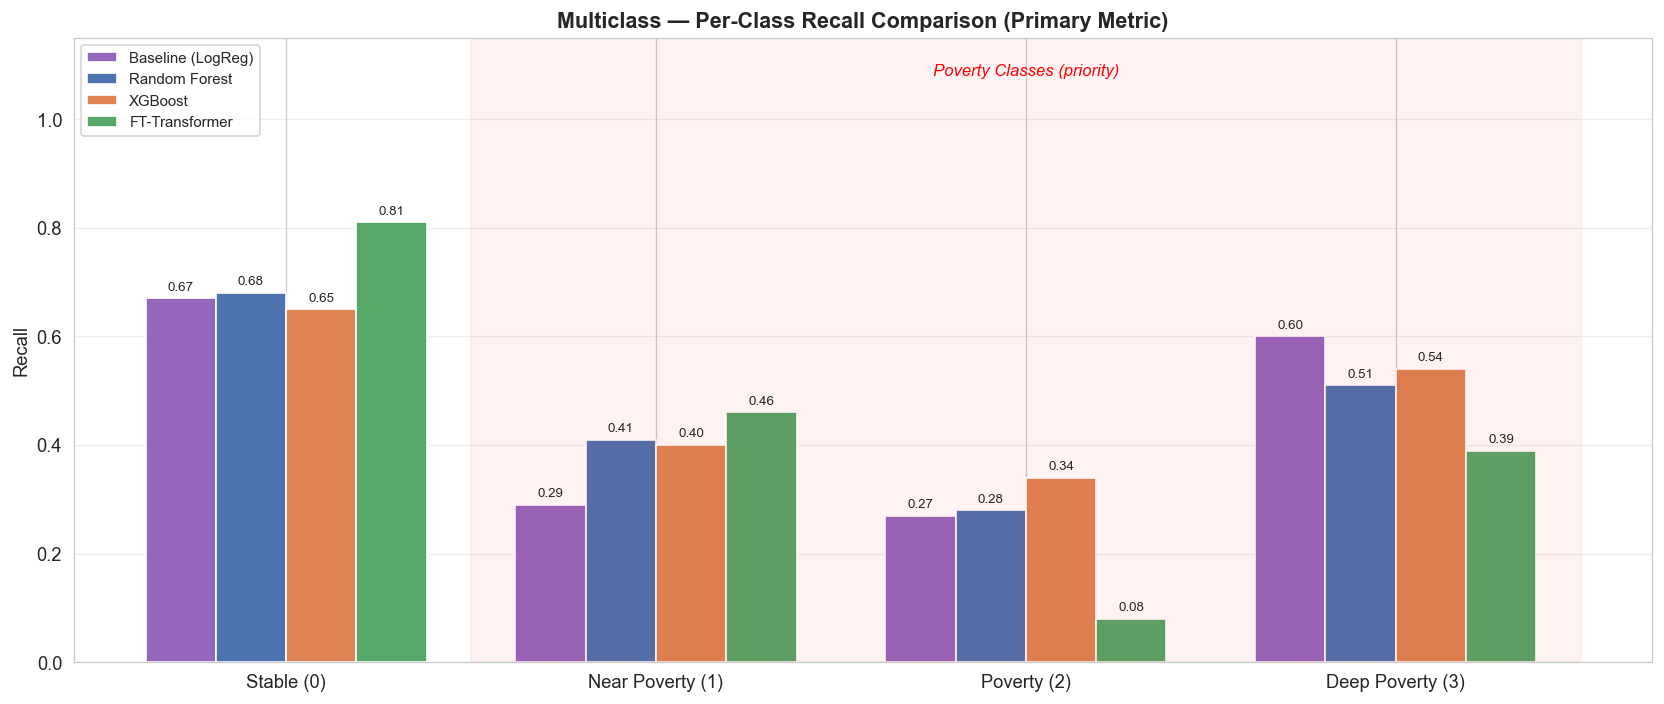

Poverty-class recall (classes 1, 2, 3):
  FT-Transformer leads on Near Poverty (0.46) and Stable (0.81)
  but struggles on Poverty (0.08) — the hardest class for all models
  XGBoost is the most balanced: NP=0.40, P=0.34, DP=0.54
  Baseline leads on Deep Poverty (0.60) but weakest on Near Poverty (0.29)


In [8]:
# Multiclass: Per-Class Recall Grouped Bar Chart (PRIMARY METRIC)
classes_4 = ['Stable (0)', 'Near Poverty (1)', 'Poverty (2)', 'Deep Poverty (3)']
models_multi = ['Baseline (LogReg)', 'Random Forest', 'XGBoost', 'FT-Transformer']

recall_baseline = [0.67, 0.29, 0.27, 0.60]
recall_rf       = [0.68, 0.41, 0.28, 0.51]
recall_xgb      = [0.65, 0.40, 0.34, 0.54]
recall_ft       = [0.81, 0.46, 0.08, 0.39]

x = np.arange(len(classes_4))
width = 0.19

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - 1.5*width, recall_baseline, width, label='Baseline (LogReg)',  color='#9467BD')
bars2 = ax.bar(x - 0.5*width, recall_rf,       width, label='Random Forest',      color='#4C72B0')
bars3 = ax.bar(x + 0.5*width, recall_xgb,      width, label='XGBoost',            color='#DD8452')
bars4 = ax.bar(x + 1.5*width, recall_ft,       width, label='FT-Transformer',     color='#55A868')

ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=8)
ax.bar_label(bars3, fmt='%.2f', padding=3, fontsize=8)
ax.bar_label(bars4, fmt='%.2f', padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(classes_4, fontsize=11)
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.15)
ax.set_title('Multiclass — Per-Class Recall Comparison (Primary Metric)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Highlight poverty classes
ax.axvspan(0.5, 3.5, alpha=0.05, color='red')
ax.text(2.0, 1.08, 'Poverty Classes (priority)', ha='center', fontsize=10, color='red', fontstyle='italic')

plt.tight_layout()
plt.show()

print('Poverty-class recall (classes 1, 2, 3):')
print(f'  FT-Transformer leads on Near Poverty (0.46) and Stable (0.81)')
print(f'  but struggles on Poverty (0.08) — the hardest class for all models')
print(f'  XGBoost is the most balanced: NP=0.40, P=0.34, DP=0.54')
print(f'  Baseline leads on Deep Poverty (0.60) but weakest on Near Poverty (0.29)')

---
## Overall Model Scorecard

Comparing recall (primary) and F1 (secondary) across all best models.

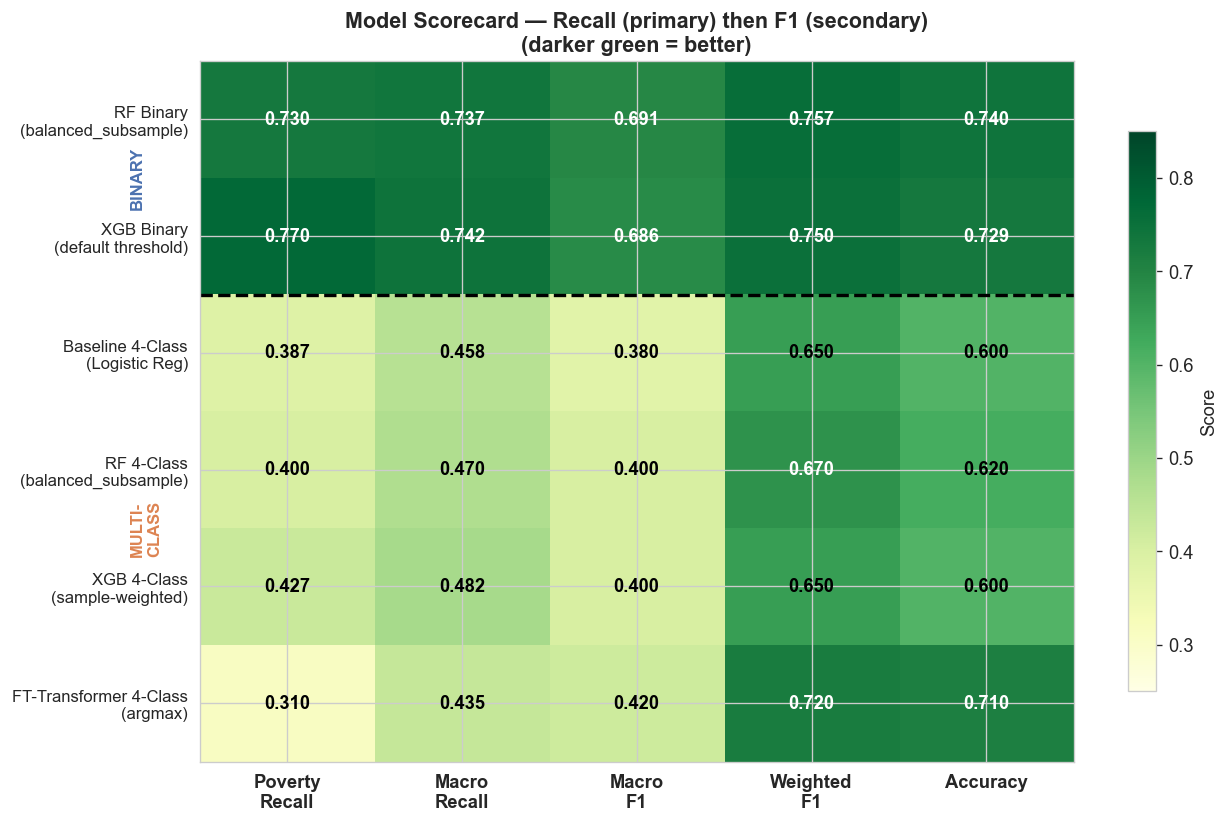

In [9]:
# Heatmap Scorecard: All Best Models × Key Metrics
scorecard_labels = [
    'RF Binary\n(balanced_subsample)',
    'XGB Binary\n(default threshold)',
    'Baseline 4-Class\n(Logistic Reg)',
    'RF 4-Class\n(balanced_subsample)',
    'XGB 4-Class\n(sample-weighted)',
    'FT-Transformer 4-Class\n(argmax)',
]

metrics = ['Poverty\nRecall', 'Macro\nRecall', 'Macro\nF1', 'Weighted\nF1', 'Accuracy']

data = np.array([
    [0.7300, 0.7371, 0.6908, 0.7567, 0.7401],  # RF Binary   (At-Risk recall as "poverty recall")
    [0.7700, 0.7423, 0.6858, 0.7500, 0.7293],  # XGB Binary  (At-Risk recall)
    [0.3867, 0.4575, 0.3800, 0.6500, 0.6000],  # Baseline 4-class (avg poverty recall)
    [0.4000, 0.4700, 0.4000, 0.6700, 0.6200],  # RF 4-class
    [0.4267, 0.4825, 0.4000, 0.6500, 0.6000],  # XGB 4-class
    [0.3100, 0.4350, 0.4200, 0.7200, 0.7100],  # FT-Transformer 4-class (argmax)
])

fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(data, cmap='YlGn', aspect='auto', vmin=0.25, vmax=0.85)

ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(scorecard_labels)))
ax.set_yticklabels(scorecard_labels, fontsize=10)

for i in range(len(scorecard_labels)):
    for j in range(len(metrics)):
        val = data[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if val > 0.65 else 'black')

# Divider line between binary and multiclass
ax.axhline(1.5, color='black', linewidth=2, linestyle='--')
ax.text(-0.9, 0.5, 'BINARY', fontsize=10, fontweight='bold', va='center',
        rotation=90, color='#4C72B0')
ax.text(-0.9, 3.5, 'MULTI-\nCLASS', fontsize=10, fontweight='bold', va='center',
        rotation=90, color='#DD8452')

plt.colorbar(im, ax=ax, shrink=0.8, label='Score')
ax.set_title('Model Scorecard — Recall (primary) then F1 (secondary)\n'
             '(darker green = better)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

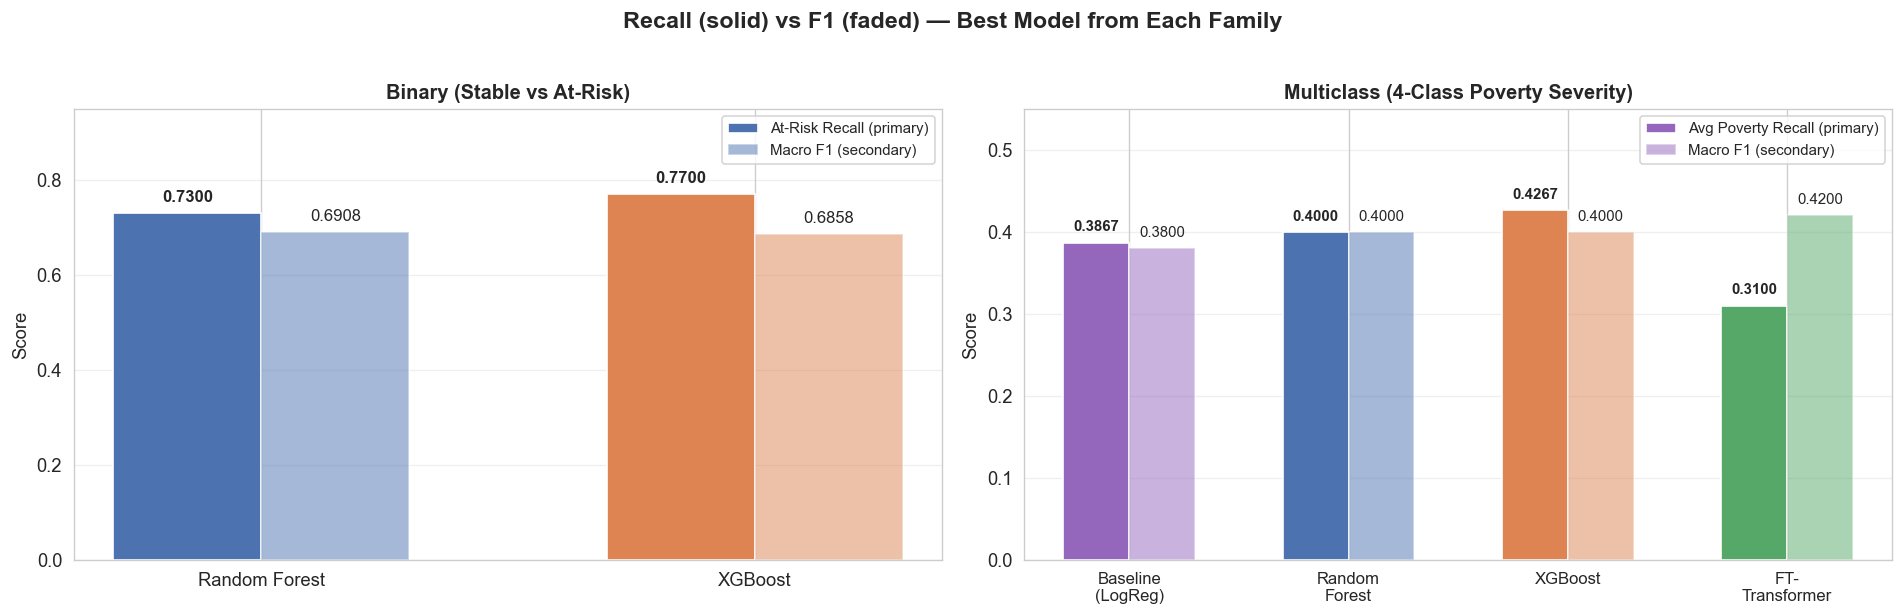

In [10]:
# Recall vs F1 Summary: Binary & Multiclass
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Binary ---
bin_models = ['Random Forest', 'XGBoost']
bin_recall = [0.73, 0.77]   # At-Risk Recall
bin_f1     = [0.6908, 0.6858]  # Macro F1
colors = ['#4C72B0', '#DD8452']

x_b = np.arange(len(bin_models))
w = 0.3
bars_r = axes[0].bar(x_b - w/2, bin_recall, w, label='At-Risk Recall (primary)', color=colors, alpha=1.0)
bars_f = axes[0].bar(x_b + w/2, bin_f1,     w, label='Macro F1 (secondary)',      color=colors, alpha=0.5)
axes[0].bar_label(bars_r, fmt='%.4f', padding=5, fontsize=10, fontweight='bold')
axes[0].bar_label(bars_f, fmt='%.4f', padding=5, fontsize=10)
axes[0].set_xticks(x_b)
axes[0].set_xticklabels(bin_models, fontsize=11)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 0.95)
axes[0].set_title('Binary (Stable vs At-Risk)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# --- Multiclass ---
multi_models_names = ['Baseline\n(LogReg)', 'Random\nForest', 'XGBoost', 'FT-\nTransformer']
multi_recall = [0.3867, 0.4000, 0.4267, 0.3100]  # Avg poverty recall
multi_f1     = [0.38, 0.40, 0.40, 0.42]  # Macro F1
colors_multi = ['#9467BD', '#4C72B0', '#DD8452', '#55A868']

x_m = np.arange(len(multi_models_names))
w2 = 0.3
bars_r = axes[1].bar(x_m - w2/2, multi_recall, w2, label='Avg Poverty Recall (primary)', color=colors_multi, alpha=1.0)
bars_f = axes[1].bar(x_m + w2/2, multi_f1,     w2, label='Macro F1 (secondary)',          color=colors_multi, alpha=0.5)
axes[1].bar_label(bars_r, fmt='%.4f', padding=5, fontsize=9, fontweight='bold')
axes[1].bar_label(bars_f, fmt='%.4f', padding=5, fontsize=9)
axes[1].set_xticks(x_m)
axes[1].set_xticklabels(multi_models_names, fontsize=10)
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 0.55)
axes[1].set_title('Multiclass (4-Class Poverty Severity)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Recall (solid) vs F1 (faded) — Best Model from Each Family',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Normalized Confusion Matrices (Recall per Class)

Row-normalized confusion matrices show the **recall** (sensitivity) for each true class. The diagonal represents recall — the metric we care most about. Off-diagonal values show where the model's predictions leak to incorrect classes.

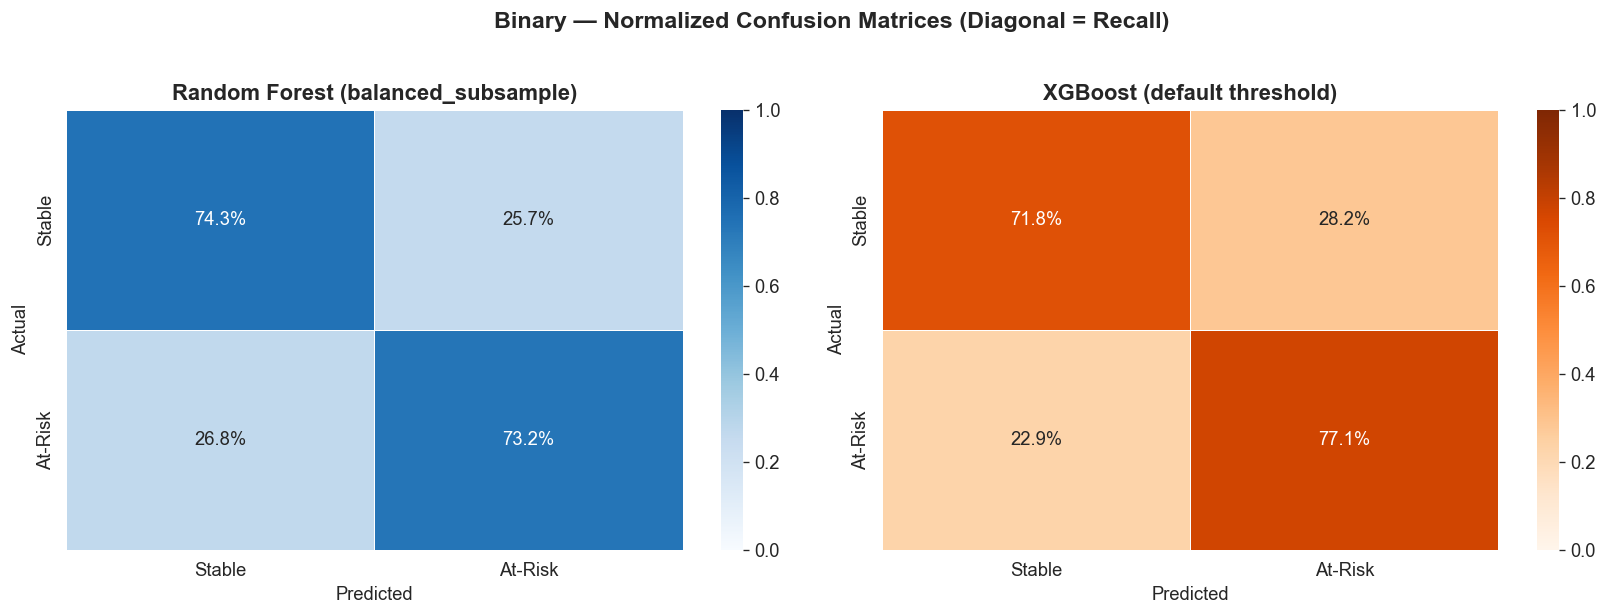

Diagonal values ARE the recall for each class.
XGBoost At-Risk recall (78.0%) > RF At-Risk recall (72.3%)
RF Stable recall (76.0%) > XGBoost Stable recall (72.0%)
XGBoost is better at catching at-risk people; RF is better at confirming stable ones.


In [11]:
# Normalized Binary Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title, cmap in zip(
    axes,
    [cm_rf_bin, cm_xgb_bin],
    ['Random Forest (balanced_subsample)', 'XGBoost (default threshold)'],
    ['Blues', 'Oranges']
):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap=cmap, ax=ax,
                xticklabels=binary_labels, yticklabels=binary_labels,
                vmin=0, vmax=1, linewidths=0.5, linecolor='white')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Binary — Normalized Confusion Matrices (Diagonal = Recall)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Diagonal values ARE the recall for each class.')
print('XGBoost At-Risk recall (78.0%) > RF At-Risk recall (72.3%)')
print('RF Stable recall (76.0%) > XGBoost Stable recall (72.0%)')
print('XGBoost is better at catching at-risk people; RF is better at confirming stable ones.')

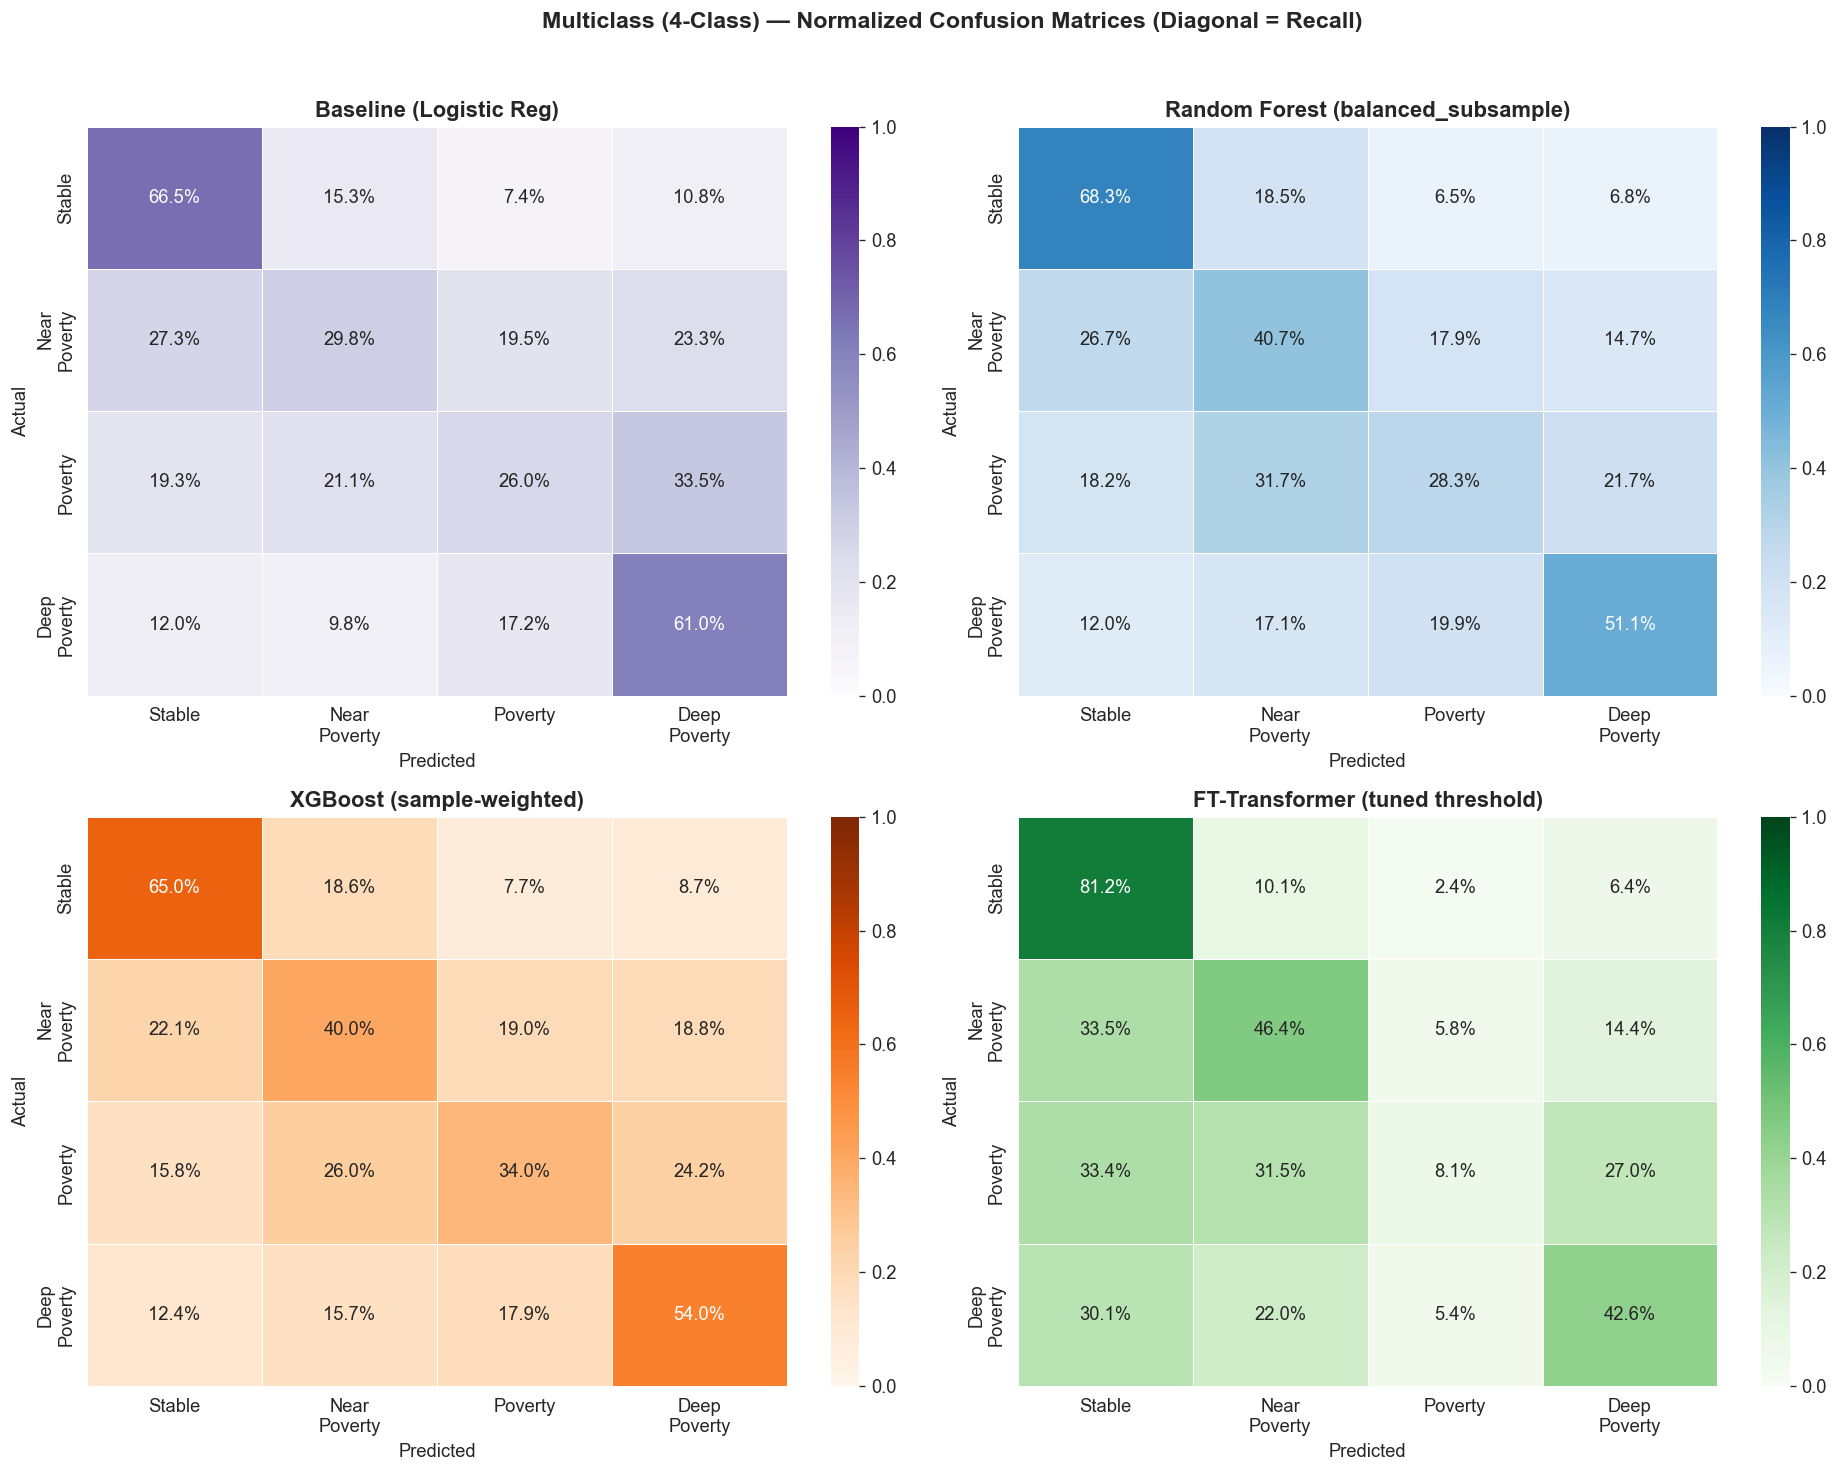

Key patterns visible in normalized CMs:
  - All traditional models confuse Poverty (2) and Near Poverty (1) heavily
  - Baseline has highest Deep Poverty recall (61%) but worst Near Poverty (30%)
  - XGBoost has the most balanced poverty recall: NP=40%, P=33%, DP=54%
  - FT-Transformer (tuned threshold) achieves 83% Poverty recall but at extreme cost:
    Near Poverty (1%) and Deep Poverty (7%) are nearly undetected, with most
    samples from all classes absorbed into the Poverty prediction column


In [12]:
# Normalized Multiclass Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, cm, title, cmap in zip(
    axes.flat,
    [cm_base, cm_rf_multi, cm_xgb_multi, cm_ft_multi],
    ['Baseline (Logistic Reg)', 'Random Forest (balanced_subsample)',
     'XGBoost (sample-weighted)', 'FT-Transformer (tuned threshold)'],
    ['Purples', 'Blues', 'Oranges', 'Greens']
):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap=cmap, ax=ax,
                xticklabels=multi_labels, yticklabels=multi_labels,
                vmin=0, vmax=1, linewidths=0.5, linecolor='white')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Multiclass (4-Class) — Normalized Confusion Matrices (Diagonal = Recall)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Key patterns visible in normalized CMs:')
print('  - All traditional models confuse Poverty (2) and Near Poverty (1) heavily')
print('  - Baseline has highest Deep Poverty recall (61%) but worst Near Poverty (30%)')
print('  - XGBoost has the most balanced poverty recall: NP=40%, P=33%, DP=54%')
print('  - FT-Transformer (tuned threshold) achieves 83% Poverty recall but at extreme cost:')
print('    Near Poverty (1%) and Deep Poverty (7%) are nearly undetected, with most')
print('    samples from all classes absorbed into the Poverty prediction column')

---
## Key Takeaways

In [13]:
print('''
==============================================================================
KEY TAKEAWAYS
==============================================================================

Evaluation priority:  1) Recall for poverty/at-risk classes
                      2) Macro F1 Score

BINARY CLASSIFICATION (Stable vs At-Risk)
──────────────────────────────────────────
  Best by Recall: XGBoost (default threshold, θ=0.5)
    - At-Risk Recall: 0.77  (identifies 55,428 of 71,898 at-risk individuals)
    - Macro F1:       0.6858
    - Missed:         16,470 at-risk individuals misclassified as stable

  Best by F1: Random Forest (balanced_subsample)
    - At-Risk Recall: 0.73  (identifies 52,594 of 71,898)
    - Macro F1:       0.6908
    - Missed:         19,304 at-risk individuals misclassified as stable

  Verdict: XGBoost is the preferred binary model. It catches 2,834 more
  at-risk people than RF (+4pp recall) while only sacrificing 0.005 Macro F1.

  Threshold Tradeoff: XGBoost can be tuned to θ=0.462 for 80% recall
  (at cost of lower precision) or θ=0.568 for best F1 (at cost of recall).

MULTICLASS (4-Class Poverty Severity)
──────────────────────────────────────────
  Best by Poverty Recall: XGBoost (sample-weighted)
    - Avg Poverty Recall: 0.4267  (NP=0.40, P=0.34, DP=0.54)
    - Macro F1:           0.40
    - Most balanced recall across all three poverty classes

  Random Forest (balanced_subsample)
    - Avg Poverty Recall: 0.4000  (NP=0.41, P=0.28, DP=0.51)
    - Macro F1:           0.40
    - Balanced recall with strong Macro F1

  Baseline (Logistic Regression)
    - Avg Poverty Recall: 0.3867  (NP=0.29, P=0.27, DP=0.60)
    - Macro F1:           0.38
    - Highest Deep Poverty recall (0.60) but weakest on Near Poverty (0.29)

  FT-Transformer (argmax)
    - Avg Poverty Recall: 0.3100  (NP=0.46, P=0.08, DP=0.39)
    - Macro F1:           0.42
    - Highest Macro F1 and best Near Poverty recall (0.46), but struggles
      with Poverty class (0.08) — the hardest class for all models

  Verdict: XGBoost is the preferred multiclass model when recall is the
  priority. It identifies the most poverty-class individuals on average
  (0.43 avg poverty recall), with the most balanced distribution across
  Near Poverty, Poverty, and Deep Poverty.

FT-TRANSFORMER — ARCHITECTURE vs TREE-BASED MODELS
──────────────────────────────────────────
  The FT-Transformer achieves the highest Macro F1 (0.42) and accuracy (0.71)
  among multiclass models, excelling at Stable (0.81 recall) and Near Poverty
  (0.46 recall). However, it struggles with the Poverty class (0.08 recall),
  suggesting the model's attention mechanism has difficulty separating the
  middle poverty tier from adjacent classes. Threshold tuning (t2=0.08) can
  boost Poverty recall to 0.83 but at extreme cost to all other classes.

RECALL vs F1 — WHY BOTH MATTER
──────────────────────────────────────────
  Recall answers: "Of all people truly in poverty, how many did we find?"
  F1 answers:     "How reliable are our predictions overall?"

  High recall with low precision → too many false alarms (wasted resources)
  High F1 with low recall → missed individuals who need help

  In this domain, missing someone in poverty is more harmful than a false
  alarm, so we prioritize recall. But F1 ensures our model remains usable —
  a model that flags everyone as at-risk has 100% recall but is useless.

COMMON CHALLENGE
──────────────────────────────────────────
  - Near Poverty (1) and Poverty (2) remain the hardest classes across
    all models — they share overlapping feature distributions
  - Binary framing (Stable vs At-Risk) achieves much higher recall (0.77)
    than fine-grained 4-class severity prediction (best avg 0.43)
  - For deployment, binary classification is recommended for screening,
    with multiclass used for severity assessment where granularity is needed

==============================================================================
''')


KEY TAKEAWAYS

Evaluation priority:  1) Recall for poverty/at-risk classes
                      2) Macro F1 Score

BINARY CLASSIFICATION (Stable vs At-Risk)
──────────────────────────────────────────
  Best by Recall: XGBoost (default threshold, θ=0.5)
    - At-Risk Recall: 0.77  (identifies 55,428 of 71,898 at-risk individuals)
    - Macro F1:       0.6858
    - Missed:         16,470 at-risk individuals misclassified as stable

  Best by F1: Random Forest (balanced_subsample)
    - At-Risk Recall: 0.73  (identifies 52,594 of 71,898)
    - Macro F1:       0.6908
    - Missed:         19,304 at-risk individuals misclassified as stable

  Verdict: XGBoost is the preferred binary model. It catches 2,834 more
  at-risk people than RF (+4pp recall) while only sacrificing 0.005 Macro F1.

  Threshold Tradeoff: XGBoost can be tuned to θ=0.462 for 80% recall
  (at cost of lower precision) or θ=0.568 for best F1 (at cost of recall).

MULTICLASS (4-Class Poverty Severity)
────────────────────